# Telecom Churn Model using Logistic Regression
A sample of 3333 active customers was randomly selected from the entire customer base from a US-owned telecommunications company. Based on earlier studies, the company found out that the customer demographic and socio-economic factors were not significant predictors of churn. So, this study focuses only on the ‘call related’ parameters, like call duration during various times of the day, number of cals, call costs and calls made to the call center etc.

Telecom companies have used two approaches to address churn - (a) Untargeted approach and **(b) Targeted approach. The untargeted approach relies on superior product and mass advertising to increase brand loyalty and thus retain customers. The targeted approach relies on identifying customers who are likely to churn, and provide suitable intervention to encourage them to stay. In the targeted approach the company tries to identify in advance customers who are likely to churn. We'll try to develop an algorithm to predict the churn score based on usage pattern. **

## Predictors in the data set
|Feature|Explanation|
|---------|-----------|
|State|Geographic location of the customer|
|Account Length|Length of time customer has been with the company|
|Area Code|Prefix of the phone number|
|Phone|Phone number|
|Int'l Plan|Customer has a plan for International calls?|
|VMail Plan|Customer has a VMail plan?|
|VMail Message|Number of VMail messages|
|Day Mins|Length of day-time calls|
|Day Calls|Number of day-time calls|
|Day Charge|Cost of day-time calls|
|Eve Mins|Length of evening calls|
|Eve Calls|Number of evening calls|
|Eve Charge|Cost of evening calls|
|Night Mins|Length of night-time calls|
|Night Calls|Number of night-time calls|
|Night Charge|Cost of night-time calls|
|Intl Mins|Length of international calls|
|Intl Calls|Number of international calls|
|Intl Charge|Cost of international calls|
|CustServ Calls|Number of calls made to Call Center|
|Churn?|Customer churned or not? (our label)|

## Step 1: Loading the data file

In [86]:
df = read.csv("churn.txt")

In [2]:
head(df)

,State,Account.Length,Area.Code,Phone,Int.l.Plan,VMail.Plan,VMail.Message,Day.Mins,Day.Calls,Day.Charge,⋯,Eve.Calls,Eve.Charge,Night.Mins,Night.Calls,Night.Charge,Intl.Mins,Intl.Calls,Intl.Charge,CustServ.Calls,Churn.
,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<int>,<dbl>,⋯,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<int>,<chr>
1,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,⋯,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False.
2,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,⋯,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False.
3,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,⋯,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False.
4,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,⋯,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
5,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,⋯,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.
6,AL,118,510,391-8027,yes,no,0,223.4,98,37.98,⋯,101,18.75,203.9,118,9.18,6.3,6,1.70,0,False.


In [3]:
str(df)

'data.frame':	3333 obs. of  21 variables:
 $ State         : chr  "KS" "OH" "NJ" "OH" ...
 $ Account.Length: int  128 107 137 84 75 118 121 147 117 141 ...
 $ Area.Code     : int  415 415 415 408 415 510 510 415 408 415 ...
 $ Phone         : chr  "382-4657" "371-7191" "358-1921" "375-9999" ...
 $ Int.l.Plan    : chr  "no" "no" "no" "yes" ...
 $ VMail.Plan    : chr  "yes" "yes" "no" "no" ...
 $ VMail.Message : int  25 26 0 0 0 0 24 0 0 37 ...
 $ Day.Mins      : num  265 162 243 299 167 ...
 $ Day.Calls     : int  110 123 114 71 113 98 88 79 97 84 ...
 $ Day.Charge    : num  45.1 27.5 41.4 50.9 28.3 ...
 $ Eve.Mins      : num  197.4 195.5 121.2 61.9 148.3 ...
 $ Eve.Calls     : int  99 103 110 88 122 101 108 94 80 111 ...
 $ Eve.Charge    : num  16.78 16.62 10.3 5.26 12.61 ...
 $ Night.Mins    : num  245 254 163 197 187 ...
 $ Night.Calls   : int  91 103 104 89 121 118 118 96 90 97 ...
 $ Night.Charge  : num  11.01 11.45 7.32 8.86 8.41 ...
 $ Intl.Mins     : num  10 13.7 12.2 6.6 10.1 6

## Step 2: Preprocessing and EDA
Assuming that features like state, area code and phone number won't have a predictive power on churn, we'll drop them. You may argue that state might play a role on churn but let's pretend that it doesn't. We'll insert the Boolean (True/False) equivalents for the categorical features Intl_Plan, VMail_Plan and Churn.

In [87]:
library(dplyr)

# Drop columns by name
df <- df %>% select(-State, -Area.Code, -Phone)
# Replace 'True.' with TRUE (logical) in 'Churn' column
df <- df %>%
     rename(Churn = Churn.)
df$Churn <- df$Churn == "True."
df$Churn <- ifelse(df$Churn==TRUE,"YES","NO")
df$Churn <- as.factor(df$Churn)
# Replace 'yes'/'no' with TRUE/FALSE in 'Intl_Plan' and 'VMail_Plan'
yes_no_cols <- c("Int.l.Plan", "VMail.Plan")
df[yes_no_cols] <- lapply(df[yes_no_cols], function(x) x == "yes")

# Display the first 3 rows
head(df, 3)

,Account.Length,Int.l.Plan,VMail.Plan,VMail.Message,Day.Mins,Day.Calls,Day.Charge,Eve.Mins,Eve.Calls,Eve.Charge,Night.Mins,Night.Calls,Night.Charge,Intl.Mins,Intl.Calls,Intl.Charge,CustServ.Calls,Churn
,<int>,<lgl>,<lgl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<dbl>,<int>,<fct>
1,128,FALSE,TRUE,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,NO
2,107,FALSE,TRUE,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,NO
3,137,FALSE,FALSE,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,NO


At this point we'll explore the data by examining the cross correlation among attributes and how they vary in comparison to every other attribue in the data set. This may give us further insight with respect to the impact of all attributes to the prediction of churn.

In [ ]:
install.packages("corrplot")

corrplot 0.95 loaded



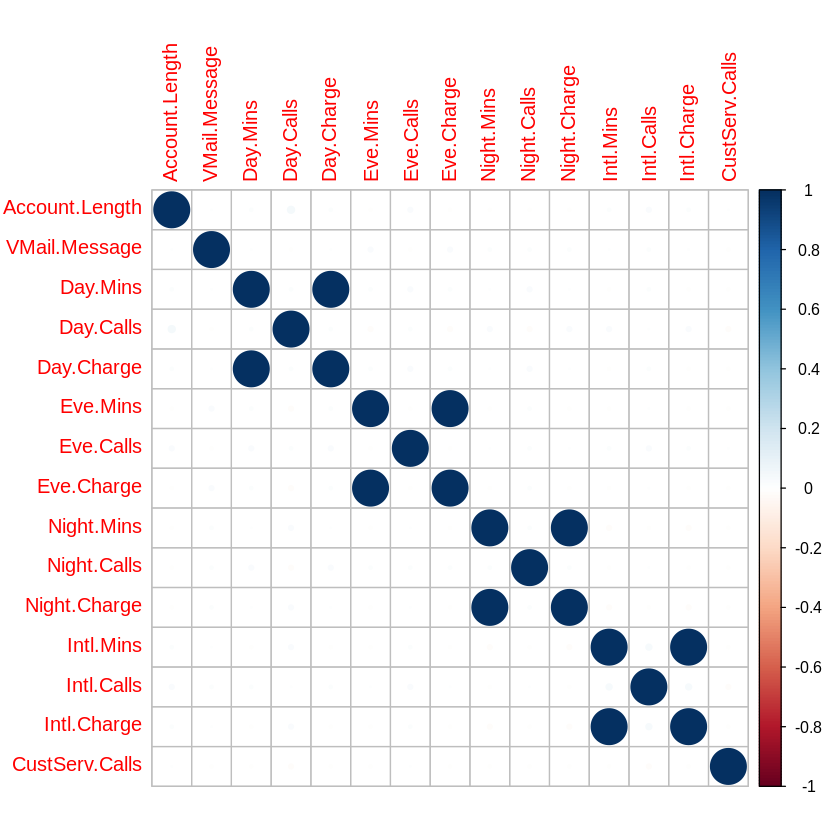

In [65]:
library("corrplot")
cor_matrix <- round(cor(df[,c(-2,-3,-18,-19)]),2) #dropping non numerical columns
#cor_matrix

corrplot(cor_matrix)


Correlation matrix for Day_Mins vs Day_Charge above show us that (VMail_Plan,VMail_Message), (Day_Mins,Day_Charge),(Eve_Mins,Eve_Charge), (Night_Mins,Night_Charge) and (Intl_Mins, Intl_Charge) pairs are perfectly correlated. So we can drop one of the features in each pair.

In [66]:
# Drop columns using dplyr's select()
df <- df %>%
  select(-Day.Charge, -Eve.Charge, -Night.Charge, -Intl.Charge)

# Get column names
col_names <- names(df)
col_names # Print out the column names

[1] "Account.Length" "Int.l.Plan"     "VMail.Plan"     "VMail.Message" 
 [5] "Day.Mins"       "Day.Calls"      "Eve.Mins"       "Eve.Calls"     
 [9] "Night.Mins"     "Night.Calls"    "Intl.Mins"      "Intl.Calls"    
[13] "CustServ.Calls" "Churn"

How is Churn distrbuted?

In [67]:
table(df$Churn)


  NO  YES 
2850  483 

In [68]:
table(df$Churn)/length(df$Churn)


       NO       YES 
0.8550855 0.1449145 

In [36]:
install.packages("GGally")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘patchwork’, ‘ggstats’




`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


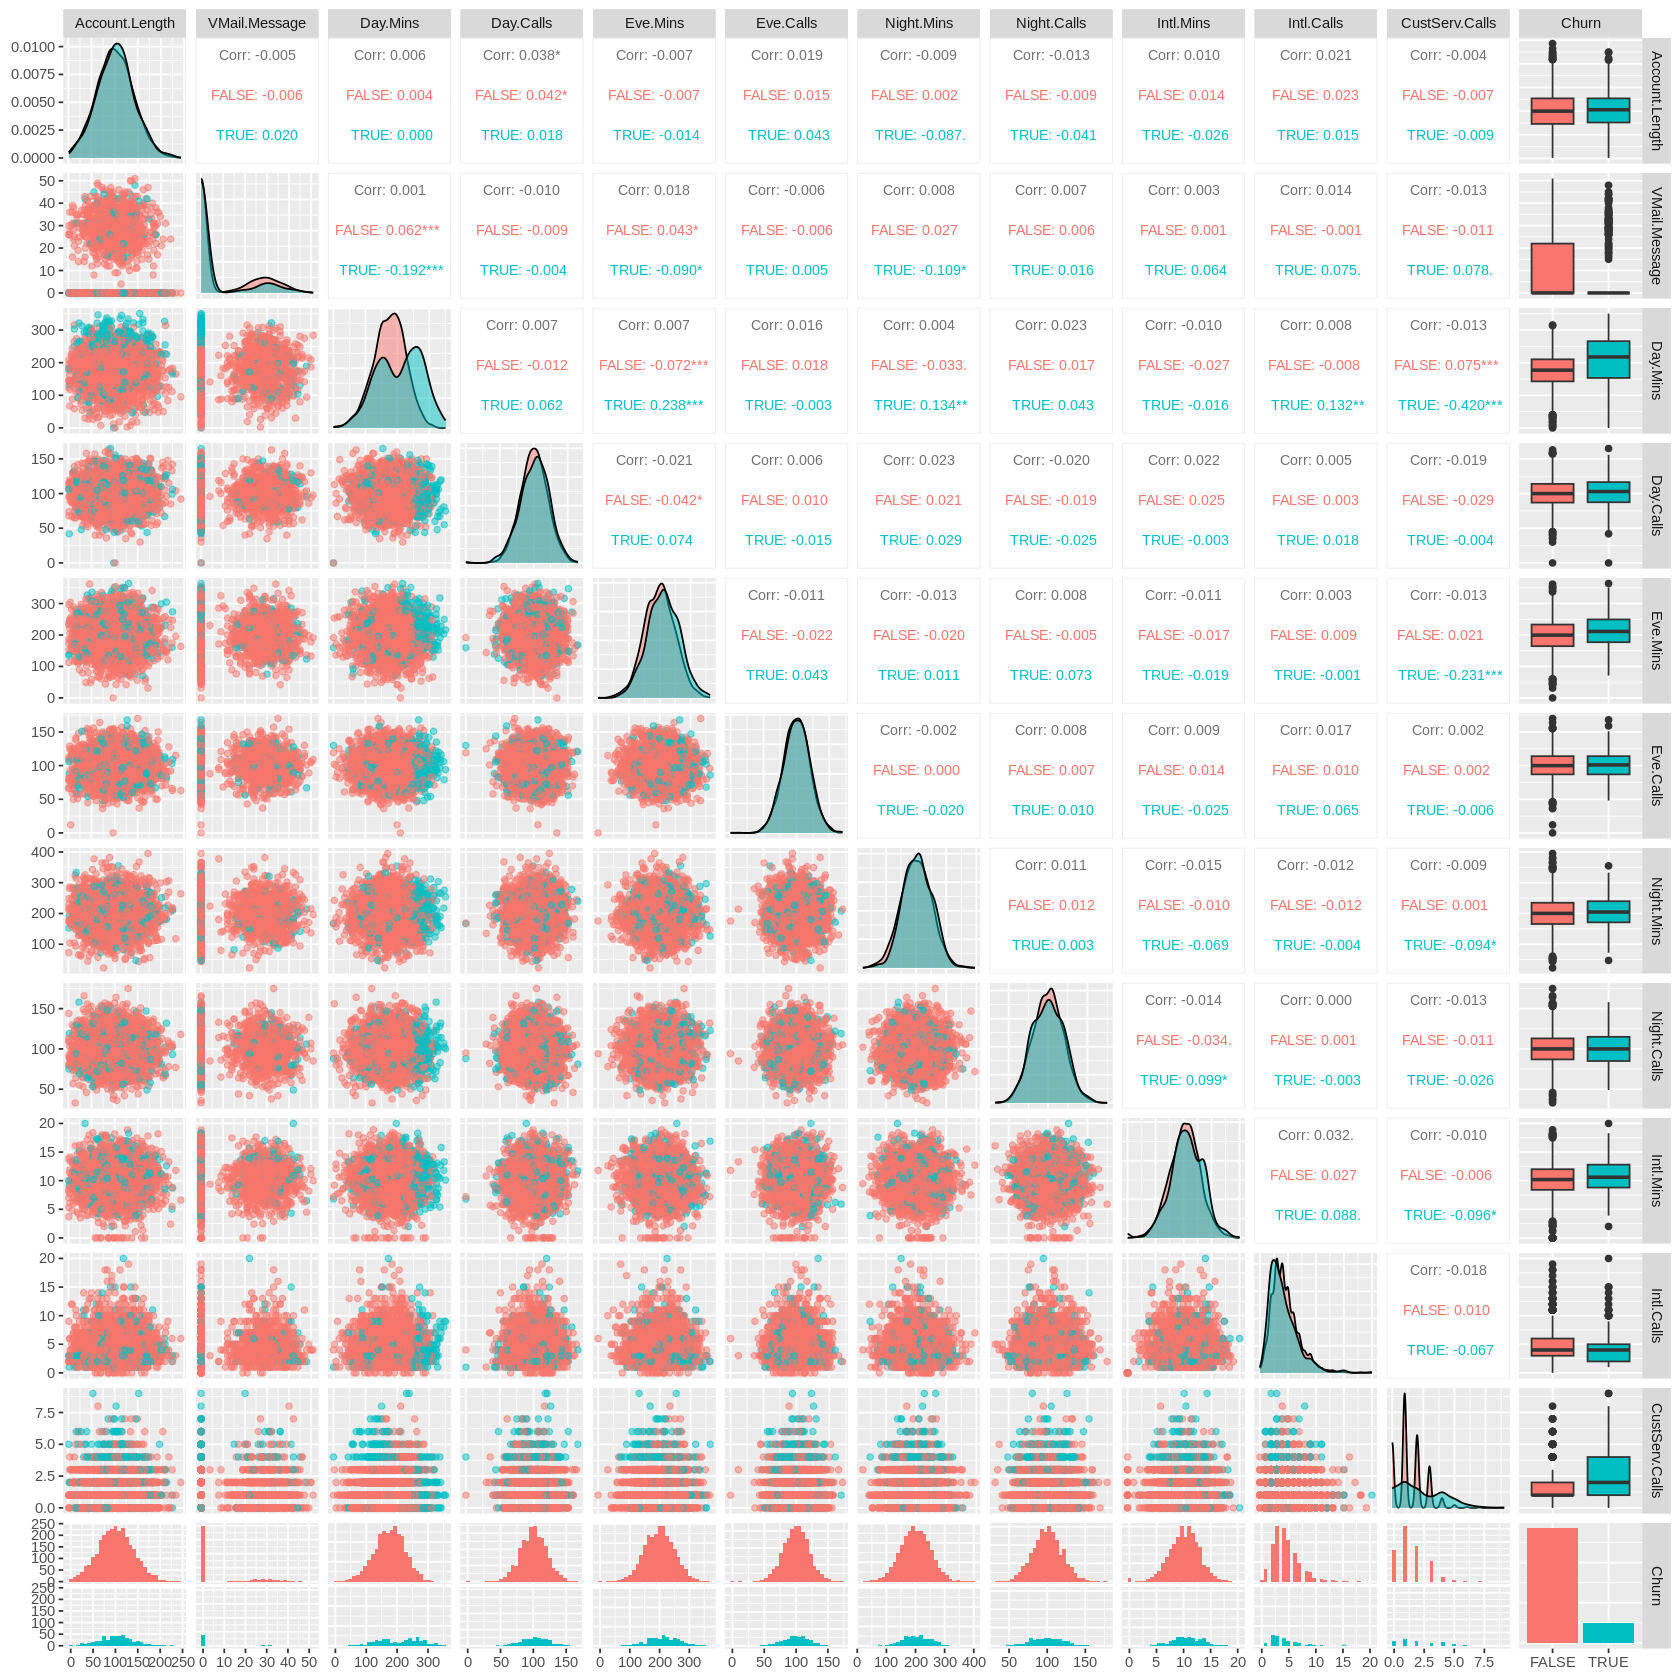

In [6]:
library(GGally)
options(repr.plot.width = 14, repr.plot.height = 14)
df_to_plot = df[,c(-2,-3,-18,-19)]
ggpairs(df_to_plot,
        columns = 1:ncol(df_to_plot),  # Select all columns
        aes(color = Churn),   # Color by Churn
        upper = list(continuous = wrap("cor", size = 3)), # Correlation values
        lower = list(continuous = wrap("points", alpha = 0.5)), # Scatter plots
        diag = list(continuous = wrap("densityDiag", alpha = 0.5)))# Density plots

Out of 3333 instances, number of customers churning is 483, non-churning 2850. We have an unbalanced data set! We have to keep this in mind for the cross-validation phase and for the evaluation of the overall prediction accuracy.<br>

Here we look at some of the attributes that we think may be important:

In [39]:
names(df)

[1] "Account.Length" "Int.l.Plan"     "VMail.Plan"     "VMail.Message" 
 [5] "Day.Mins"       "Day.Calls"      "Eve.Mins"       "Eve.Calls"     
 [9] "Night.Mins"     "Night.Calls"    "Intl.Mins"      "Intl.Calls"    
[13] "CustServ.Calls" "Churn"

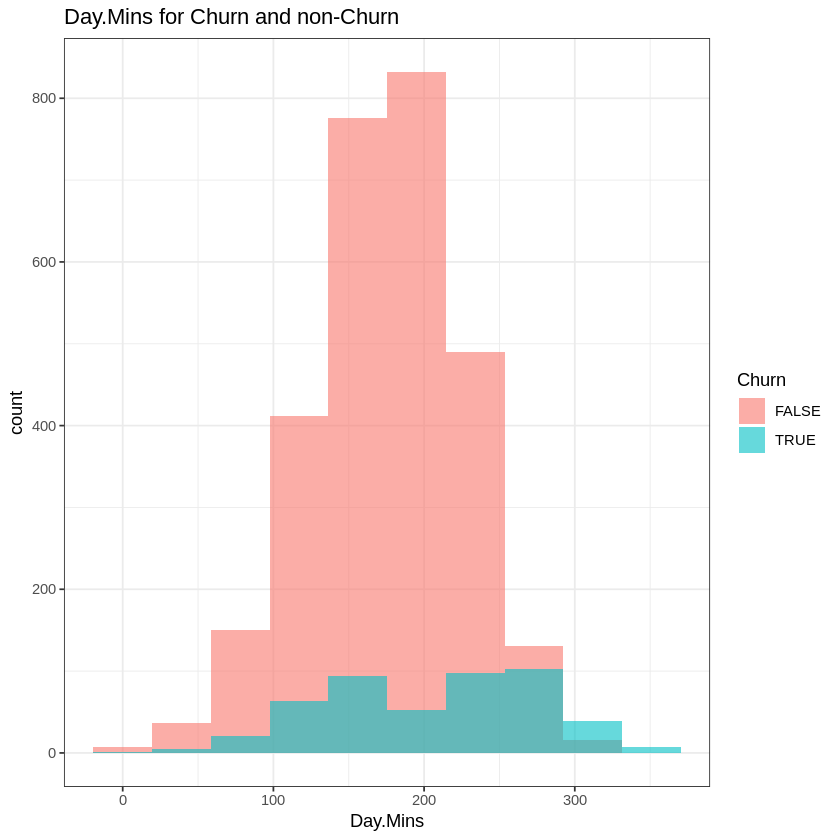

In [49]:
# Day Mins Histogram
ggplot(df, aes(x = Day.Mins, fill = Churn)) +
  geom_histogram(alpha = 0.6, position = "identity",bins = 10) +
  ggtitle("Day.Mins for Churn and non-Churn") +
  theme_bw()

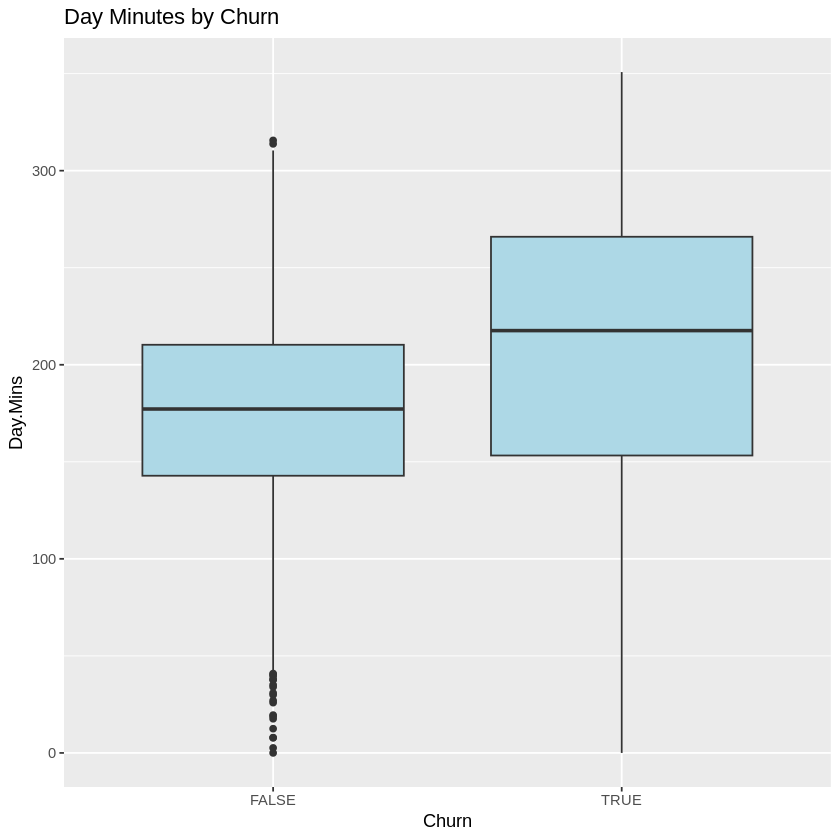

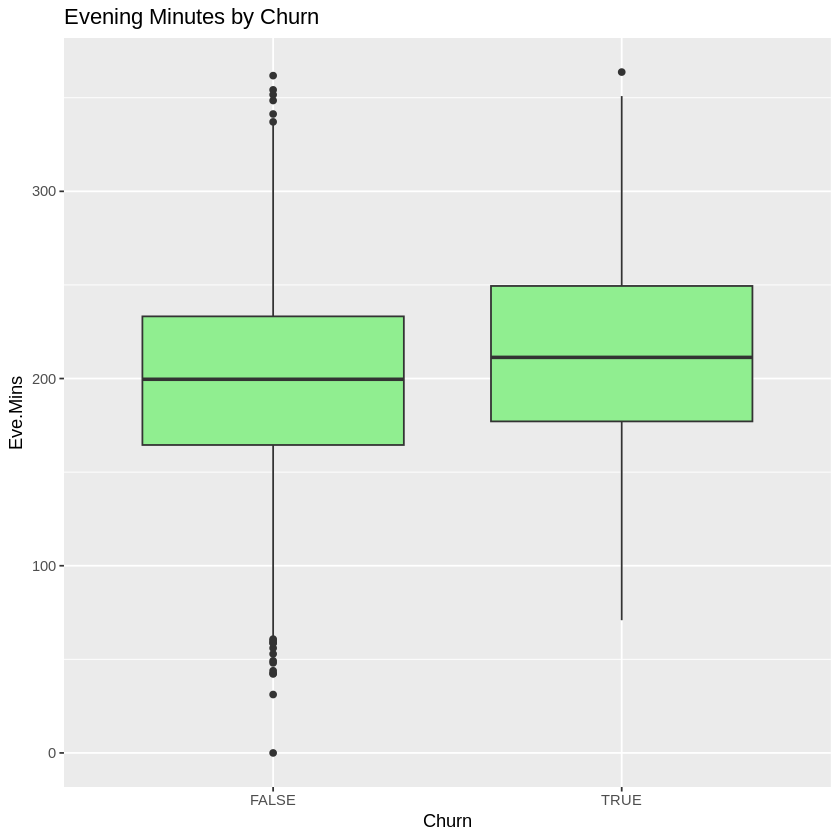

In [44]:
# Day_Mins Boxplot
ggplot(df, aes(x = Churn, y = Day.Mins)) +
  geom_boxplot(fill = "lightblue") +
  labs(title = "Day Minutes by Churn")

# Eve_Mins Boxplot
ggplot(df, aes(x = Churn, y = Eve.Mins)) +
  geom_boxplot(fill = "lightgreen") +
  labs(title = "Evening Minutes by Churn")

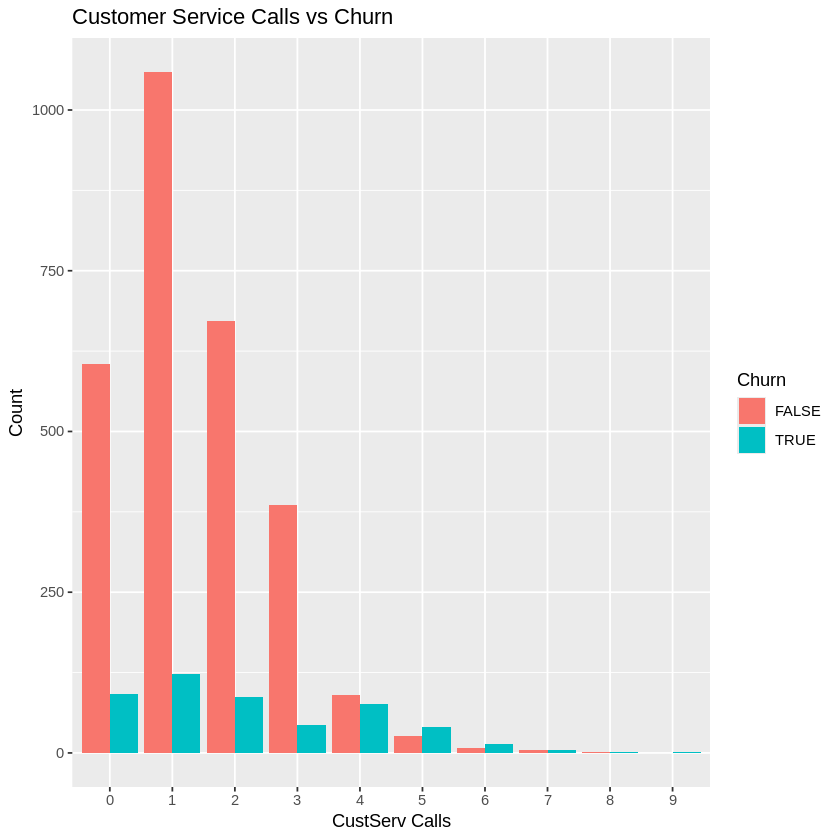

In [51]:
#Customer service calls

library(ggplot2)

# Create a contingency table
custserv_table <- as.data.frame(table(df$CustServ.Calls, df$Churn))
colnames(custserv_table) <- c("CustServ.Calls", "Churn", "Count")

# Plot grouped bar chart
ggplot(custserv_table, aes(x = CustServ.Calls, y = Count, fill = Churn)) +
  geom_bar(stat = "identity", position = position_dodge()) +
  labs(title = "Customer Service Calls vs Churn", x = "CustServ Calls", y = "Count")


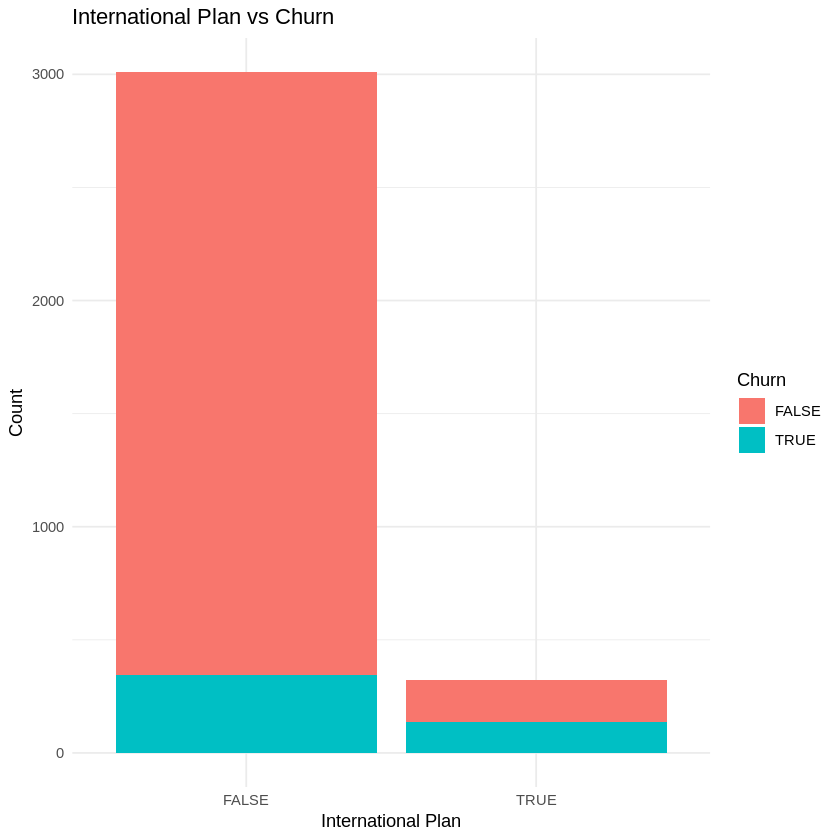

In [52]:
# international plan

library(ggplot2)

# Create a cross-tabulation and convert to dataframe
intlplan_table <- as.data.frame(table(df$Int.l.Plan, df$Churn))
colnames(intlplan_table) <- c("Int.l.Plan", "Churn", "Count")

# Plot stacked bar chart
ggplot(intlplan_table, aes(x = Int.l.Plan, y = Count, fill = Churn)) +
  geom_bar(stat = "identity", position = "stack") +
  labs(title = "International Plan vs Churn",
       x = "International Plan",
       y = "Count") +
  theme_minimal()

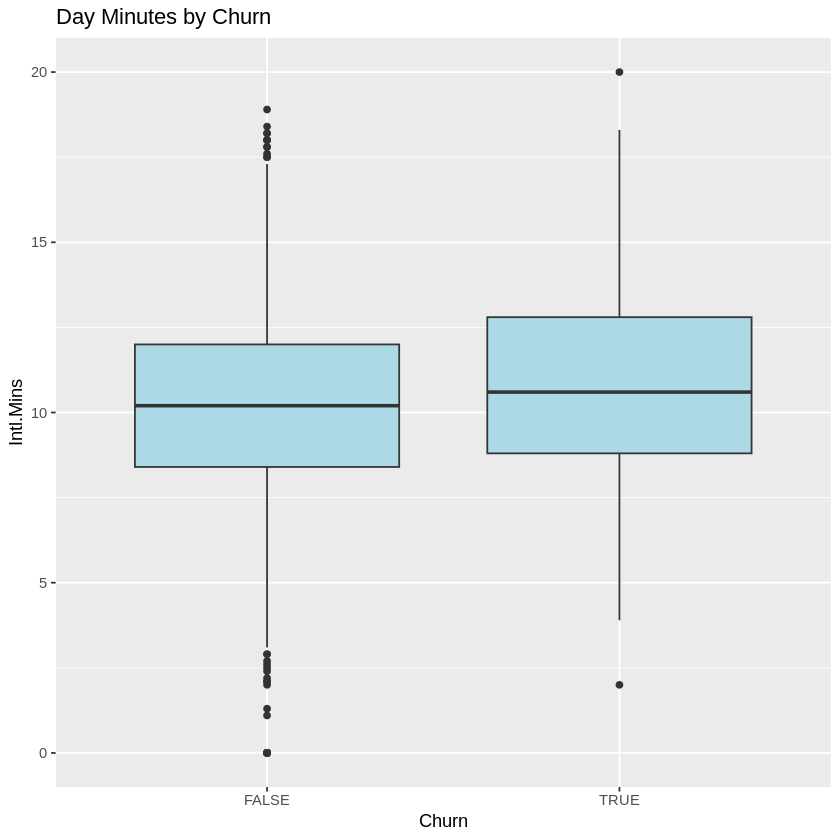

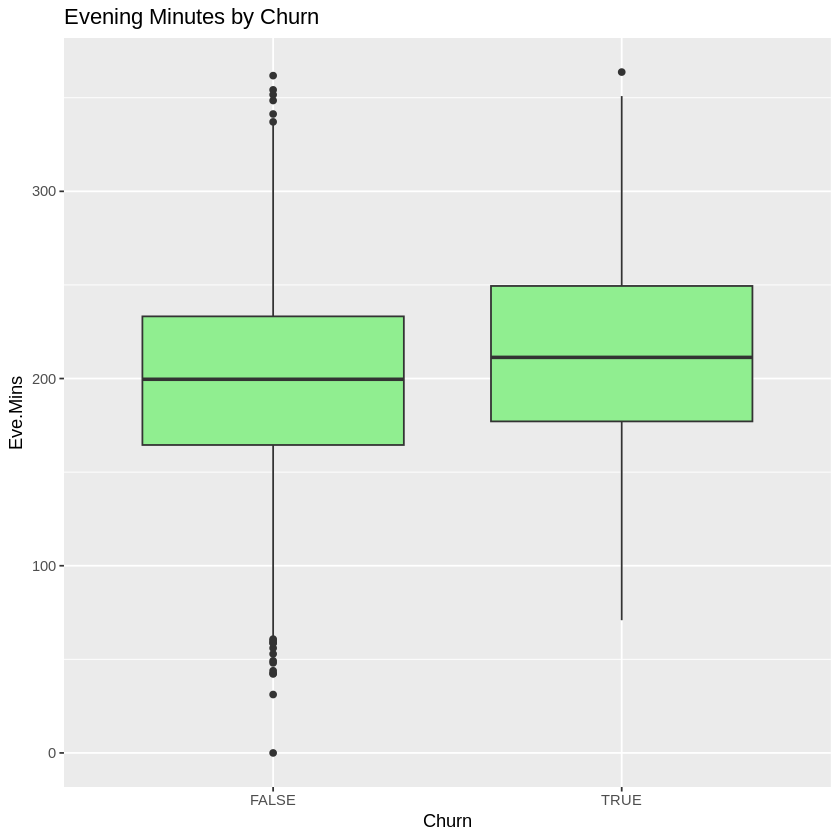

In [53]:
# international minutes and account length

# Day_Mins Boxplot
ggplot(df, aes(x = Churn, y = Intl.Mins)) +
  geom_boxplot(fill = "lightblue") +
  labs(title = "Day Minutes by Churn")

# Eve_Mins Boxplot
ggplot(df, aes(x = Churn, y = Eve.Mins)) +
  geom_boxplot(fill = "lightgreen") +
  labs(title = "Evening Minutes by Churn")

Plots above hint at a few things:
* Evening and Night time calls (or their duration) don't seem to contribute to churn.
* The length of the day-time calls, however, seems to have an impact on churn if it's longer than 250 minutes as is evident from the first plot above.
* Second plot supports this finding while the boxplot for the evening calls doesn't seem to change much for either class.
* The number of calls made to the call center seems to matter for 4 calls and above (third plot).
* In the fourth plot, it is evident that those customers with an International Plan tend to churn more (total duration of the calls doesn't seem to have mmuch effect).
* In the 5th plot, we see that a long Account_Length doesn't stop subscribers from churning.

## Step 3: Building the Model with Logistic Regression
In this step, we'll fit a Logistic Regression model to our data. We need to represent our dataframe as a matrix as expected by  the scikit module now. We convert the pandas dataframe into a numpy matrix (for both X and y) down below:

In [4]:
install.packages("ROCR")
install.packages("caret")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘future.apply’, ‘lava’, ‘prodlim’, ‘hardhat’, ‘ipred’, ‘e1071’, ‘foreach’, ‘recipes’




In [88]:


library(caret)
# set random number seed for randomized partition
# different seed values will generate different partitions of the data
# Create stratified folds
indxTrain <- createDataPartition(y = df$Churn,
                                 p = 0.7,
                                 list = FALSE,
                                 groups = length(unique(df$Churn))) # stratified folds..

# Define training and testing sets
training <- df[indxTrain, ]
testing <- df[-indxTrain, ]

In [89]:
model = glm(Churn ~ ., data=training,family = binomial)
summary(model)


Call:
glm(formula = Churn ~ ., family = binomial, data = training)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)    -9.502e+00  8.908e-01 -10.666  < 2e-16 ***
Account.Length  7.182e-04  1.670e-03   0.430 0.667186    
Int.l.PlanTRUE  2.000e+00  1.811e-01  11.043  < 2e-16 ***
VMail.PlanTRUE -2.344e+00  7.064e-01  -3.318 0.000906 ***
VMail.Message   4.463e-02  2.165e-02   2.061 0.039304 *  
Day.Mins       -3.826e+00  3.926e+00  -0.974 0.329858    
Day.Calls       1.887e-03  3.366e-03   0.561 0.575037    
Day.Charge      2.259e+01  2.310e+01   0.978 0.328138    
Eve.Mins       -1.690e+00  1.987e+00  -0.850 0.395113    
Eve.Calls       2.110e-03  3.365e-03   0.627 0.530569    
Eve.Charge      1.997e+01  2.338e+01   0.854 0.392879    
Night.Mins     -2.631e-01  1.049e+00  -0.251 0.801898    
Night.Calls     2.146e-03  3.470e-03   0.619 0.536173    
Night.Charge    5.951e+00  2.330e+01   0.255 0.798439    
Intl.Mins      -1.034e+01  6.380e+00  -1.621 0.

In [90]:

logregPredictProb <- predict(model, newdata = testing, type = "response")
logregPredictClass <- ifelse(logregPredictProb > 0.5, "YES", "NO")

# 3. Convert predicted classes to factor with same levels as the true values
logregPredictClass <- factor(logregPredictClass, levels = levels(testing$Churn))
# Now compute the confusion matrix correctly
confusionMatrix(logregPredictClass, testing$Churn, positive = "YES")

Confusion Matrix and Statistics

          Reference
Prediction  NO YES
       NO  821 105
       YES  34  39
                                          
               Accuracy : 0.8609          
                 95% CI : (0.8378, 0.8817)
    No Information Rate : 0.8559          
    P-Value [Acc > NIR] : 0.3459          
                                          
                  Kappa : 0.2907          
                                          
 Mcnemar's Test P-Value : 2.897e-09       
                                          
            Sensitivity : 0.27083         
            Specificity : 0.96023         
         Pos Pred Value : 0.53425         
         Neg Pred Value : 0.88661         
             Prevalence : 0.14414         
         Detection Rate : 0.03904         
   Detection Prevalence : 0.07307         
      Balanced Accuracy : 0.61553         
                                          
       'Positive' Class : YES             
                              

Our classification accuracy is no better than the "**Null Accuracy**", which was 85.5%.

[1] "AUC: 0.799545159194282"


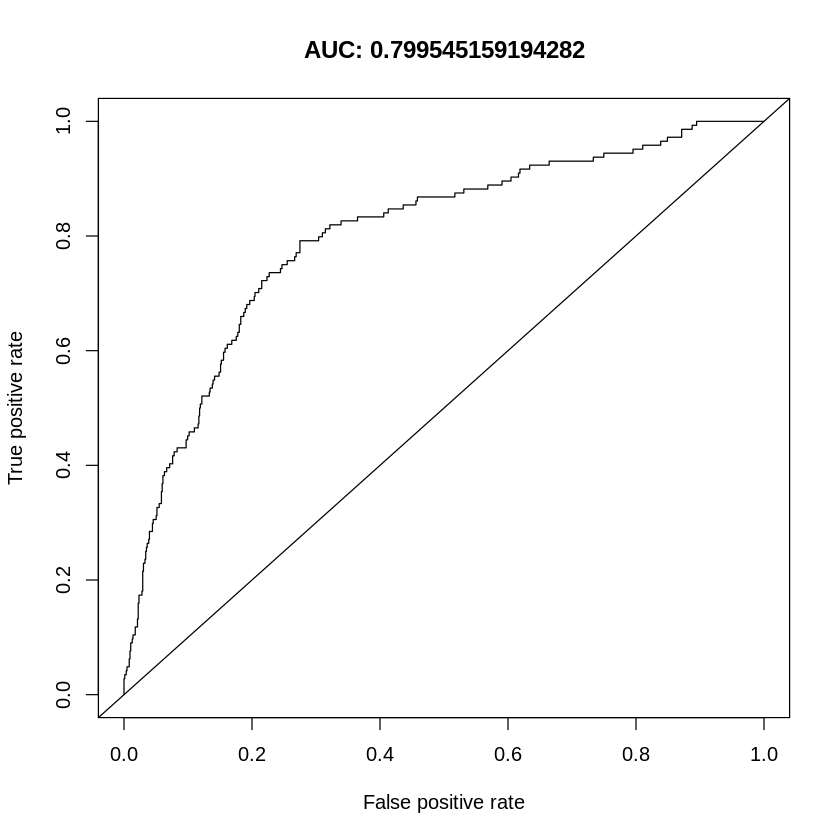

In [91]:
library(ROCR)
# data structure for constructing ROC and lift curves
pred <- prediction(logregPredictProb, testing$Churn)

# plot AUC
perAUC <- performance(pred,"tpr", "fpr")

# Calculate AUC
auc <- performance(pred, "auc")
auc <- unlist(slot(auc, "y.values"))

# Print AUC
print(paste("AUC:", auc))


plot(perAUC, main = paste("AUC:",auc))
abline(0,1)

## Step 4: Evaluation of the Model Accuracy

The model accuracy found earlier was 85.89% on the test set. Considering the unbalanced data set, which revealed proportions of 85.5% and 14.5% for non-churn and churn, respectively, this is no better than the null accuracy, which is the accuracy of the most naive model which predicts everything as "no-churn". So we're no better than this.

we need to approach this problem from a different angle.

### Breakdown of the cost:
What are the costs for my problem of mobile operator churn? The costs, of course, depend on the specific actions that the business takes. How about making some assumptions here. First, let's assign the true negatives (**TN**)the cost of **0TL**. My model essentially correctly identified a happy customer in this case, and I don’t need to do anything.

False negatives (**FN**) are the most problematic, because they incorrectly predict that a churning customer will stay. They  will lose the customer and will have to pay all the costs of acquiring a replacement customer, including foregone revenue, advertising costs, administrative costs, point of sale costs, and likely a phone hardware subsidy. For the purposes of this problem, let's assume the cost as **500TL**, which is a reasonable amount. This is the cost of false negatives (**FN**).

Finally, for customers that my model identifies as churning, I will assume a retention incentive in the amount of **100TL**. If the provider offered its subscriber a concession of this sort, the subscriber would probably think twice before leaving. This is the cost of both true positive (**TP**) and false positive (**FP**) outcomes. In the case of false positive (**FP**), the customer is happy, but the model mistakenly predicted churn. So we will “waste” the **100TL** concession. The service provider probably could have spent that **100TL** more effectively, but in the end they possibly increased the loyalty of an already loyal customer, so that’s not necessarily so bad.

**Here is the model for the cost function**:
$$Cost = 500TL * FN + 0TL * TN + 100TL * FP + 100TL * TP$$


The model predicts any input as "churn", i.e. as p(Y=1|X), whenever the probability is equal and above the threshold of 0.5 (50%). Now we will try to find the optimum threshold that minimizes the cost function we constructed above. For this, we'll compute the cost function for a range of cutoff values for the probability thresholds:

Cutoff  Cost/customer (TL)   Accuracy
0.00   100.00                0.144
0.05    71.87                0.470
0.11    57.16                0.645
0.16    50.25                0.747
0.21    49.75                0.791
0.26    52.55                0.814
0.32    54.75                0.834
0.37    55.26                0.850
0.42    57.46                0.855
0.47    58.36                0.861
0.53    60.66                0.862
0.58    64.16                0.860
0.63    66.77                0.858
0.68    68.17                0.859
0.74    69.77                0.858
0.79    70.37                0.858
0.84    70.47                0.860
0.89    71.67                0.857
0.95    72.07                0.856
1.00    72.07                0.856


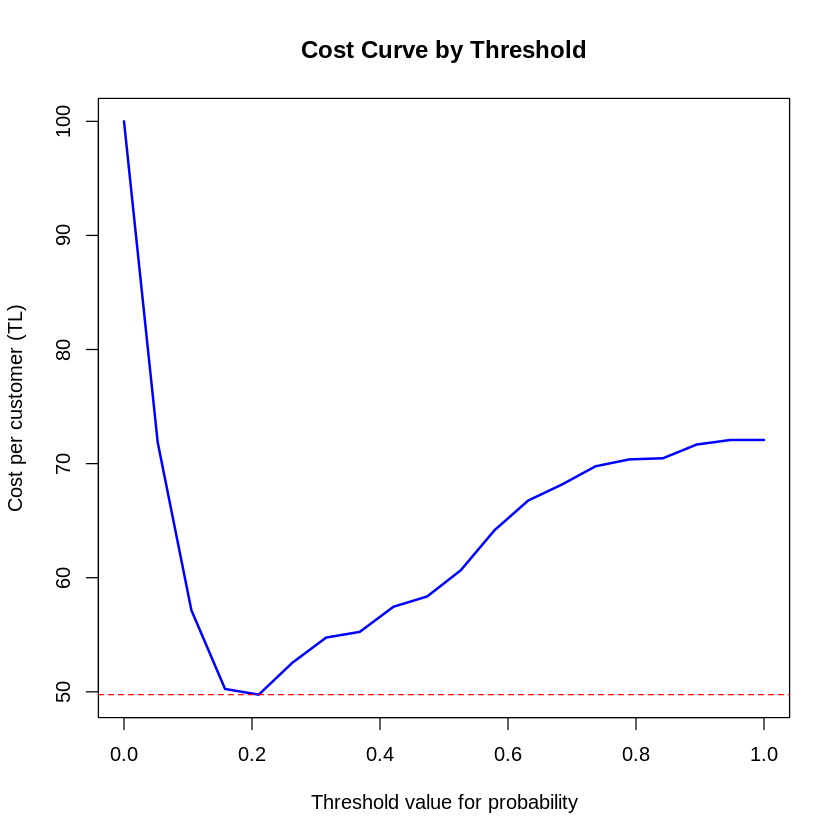

In [103]:
# Required libraries
library(caret)
library(ggplot2)

# Custom cost function
costfunc <- function(conf_matrix) {
  TP <- conf_matrix[2, 2]
  TN <- conf_matrix[1, 1]
  FP <- conf_matrix[2, 1]
  FN <- conf_matrix[1, 2]
  cost <- 500 * FN + 0 * TN + 100 * FP + 100 * TP
  return(cost)
}

# Predict probabilities
y_pred_prob <- predict(model, testing, type = "response")

Xp <- c()
Yp <- c()

cat("Cutoff  Cost/customer (TL)   Accuracy\n")

# Loop over thresholds
for (cutoff in seq(0, 1, length.out = 20)) {
  y_pred_class <- ifelse(y_pred_prob > cutoff, "YES", "NO")
  y_pred_class <- factor(y_pred_class, levels = levels(testing$Churn))

  cm <- table(Predicted = y_pred_class, Actual = testing$Churn)
  cost <- costfunc(cm)/length(testing$Churn)
  accuracy <- mean(y_pred_class == testing$Churn)

  Xp <- c(Xp, cutoff)
  Yp <- c(Yp, cost)

  cat(sprintf('%4.2f   %6.2f                %5.3f\n', cutoff, cost, accuracy))
}

# Plotting
plot(Xp, Yp, type = "l", col = "blue", lwd = 2,
     xlab = "Threshold value for probability", ylab = "Cost per customer (TL)",
     main = "Cost Curve by Threshold")
abline(h = min(Yp), col = "red", lty = 2)


### Interpretation of the current approach:
Now we're ready to compare the financial outcomes of using vs. not using this model. We can treat not using an ML model as a simple strategy–a kind of primitive model. In other words, if the provider doesn’t use ML, they're assuming that everyone is loyal and not offering anyone any concessions. They’ll be making a false negative (**FN**) type of mistake 14.5% of the time. If they want to maintain their current pool of customers, this strategy will cost them **500TL x 0.145** or **72.5TL/customer**, on average.

If the provider uses the ML model with a calculated optimal threshold of $0.21$, overall accuracy will go down to **79%**, which is lower than what we had before (the one that doesn't use a model). But the overall cost of this strategy drops to around **50TL/customer**. This is substantially better than **72.5TL/customer**. It's a much better decision to deploy the ML model!

This approach gives the provider the ability to compare the performance of different strategies–including strategies that don’t involve ML – in clear financial terms. In this example, using a Machine Learning model has a **22.5TL/customer** advantage. If the costs and assumptions are accurate, for a hypothetical small mobile operator with only 100,000 customers this equals over **2M TL** in savings!